<a href="https://colab.research.google.com/github/Vitchuvishali/HR-WORKFORCE-ANALYSIS/blob/main/HR_ATTRITION_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# PHASE 1: Data Understanding & Cleaning
import pandas as pd
from google.colab import files

uploaded = files.upload()
df = pd.read_csv("HR_Analytics1.csv")

# Understand
print(df.shape); df.info()

# Missing values
for c in df.columns:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna(df[c].median() if df[c].dtype != 'object' else df[c].mode()[0])

# Duplicates
df = df.drop_duplicates(subset="EmpID").drop_duplicates()

# Derived: Salary Band
q1, q2 = df["MonthlyIncome"].quantile([0.33, 0.66])
df["SalaryBand"] = df["MonthlyIncome"].apply(lambda x: "Low" if x<=q1 else "Medium" if x<=q2 else "High")

# Derived: Experience Group
df["ExperienceGroup"] = df["TotalWorkingYears"].apply(lambda y: "Fresher" if y<=2 else "Mid-Level" if y<=7 else "Senior")

# Derived: Retention Risk
df["RiskScore"] = ((df["JobSatisfaction"]<=2).astype(int) + (df["OverTime"]=="Yes").astype(int) +
                    (df["WorkLifeBalance"]<=2).astype(int) + (df["EnvironmentSatisfaction"]<=2).astype(int) +
                    (df["YearsSinceLastPromotion"]>=5).astype(int))
df["RetentionRisk"] = df["RiskScore"].apply(lambda s: "High Risk" if s>=3 else "Medium Risk" if s==2 else "Low Risk")

print(df["SalaryBand"].value_counts(), df["ExperienceGroup"].value_counts(), df["RetentionRisk"].value_counts(), sep="\n\n")

df.to_csv("HR_Analytics_Cleaned.csv", index=False)
df.head()

Saving HR_Analytics1.csv to HR_Analytics1 (1).csv
(1470, 50)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 50 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmpID                     1470 non-null   object 
 1   Age                       1470 non-null   int64  
 2   AgeGroup                  1470 non-null   object 
 3   Attrition                 1470 non-null   object 
 4   BusinessTravel            1470 non-null   object 
 5   DailyRate                 1470 non-null   int64  
 6   Department                1470 non-null   object 
 7   DistanceFromHome          1470 non-null   int64  
 8   Education                 1470 non-null   int64  
 9   EducationField            1470 non-null   object 
 10  EmployeeCount             1470 non-null   int64  
 11  EmployeeNumber            1470 non-null   int64  
 12  EnvironmentSatisfaction   1470 non-null   int64  
 13  Ge

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RiskScore,RetentionRisk,HireDate,ExitDate,ExitYear,HireYear,Segment_HighPerformer,Segment_LongTerm,Segment_Overtime,Segment_Dissatisfied
0,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,...,0,Low Risk,20-09-2024,27-11-2024,2024.0,2024,No,No,No,No
1,RM302,18,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,...,0,Low Risk,05-04-2024,05-06-2024,2024.0,2024,No,No,No,No
2,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,...,3,High Risk,16-09-2024,07-12-2024,2024.0,2024,No,No,Yes,Yes
3,RM728,18,18-25,No,Non-Travel,287,Research & Development,5,2,Life Sciences,...,1,Low Risk,21-10-2024,05-06-2024,2024.0,2024,No,No,No,No
4,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,...,0,Low Risk,26-06-2024,30-11-2024,2024.0,2024,No,No,No,No


In [ ]:
from google.colab import files
import pandas as pd

# Load Phase 1 cleaned dataset
uploaded = files.upload()  # upload HR_Analytics_Phase1_Cleaned.csv
df = pd.read_csv("HR_Analytics_Cleaned.csv")

# KPIs
kpis = {
    "Total Employees": len(df),
    "Attrition Rate (%)": round((df["Attrition"] == "Yes").mean() * 100, 2),
    "Employee Retention Rate (%)": round((df["Attrition"] == "No").mean() * 100, 2),
    "Average Employee Tenure (yrs)": round(df["YearsAtCompany"].mean(), 2),
    "Job Satisfaction Score (avg)": round(df["JobSatisfaction"].mean(), 2),
    "Average Income": round(df["MonthlyIncome"].mean(), 2),
    "Overtime Percentage (%)": round((df["OverTime"] == "Yes").mean() * 100, 2),
    "High Risk Employee Count": (df["RetentionRisk"] == "High Risk").sum(),
}

kpi_df = pd.DataFrame(kpis.items(), columns=["KPI", "Value"])
print(kpi_df.to_string(index=False))

kpi_df.to_csv("kpi_summary.csv", index=False)
files.download("kpi_summary.csv")

Saving HR_Analytics_Cleaned.csv to HR_Analytics_Cleaned (3).csv
                          KPI   Value
              Total Employees 1470.00
           Attrition Rate (%)   16.12
  Employee Retention Rate (%)   83.88
Average Employee Tenure (yrs)    7.01
 Job Satisfaction Score (avg)    2.73
               Average Income 6502.93
      Overtime Percentage (%)   28.30
     High Risk Employee Count  230.00


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saving HR_Analytics_Cleaned.csv to HR_Analytics_Cleaned (4).csv
KPI CARDS: {'Total Employees': 1470, 'Attrition Rate (%)': np.float64(16.12), 'Retention Rate (%)': np.float64(83.88), 'High Risk Count': np.int64(230)}


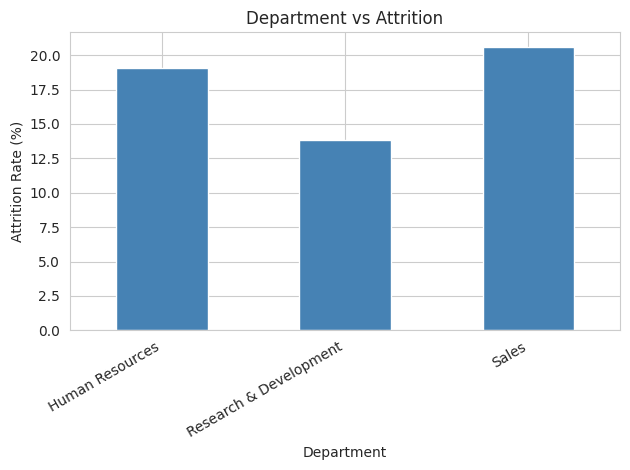

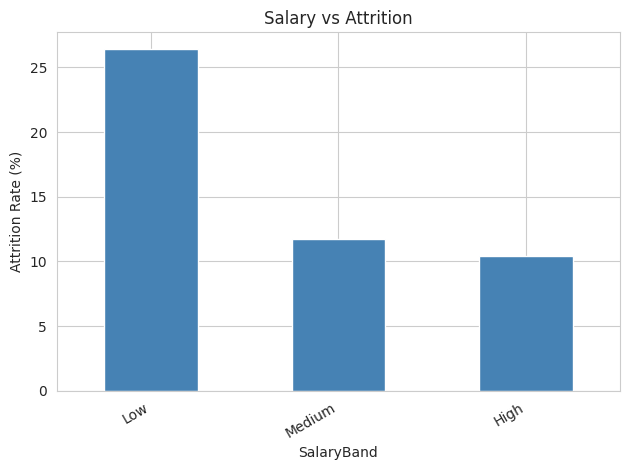

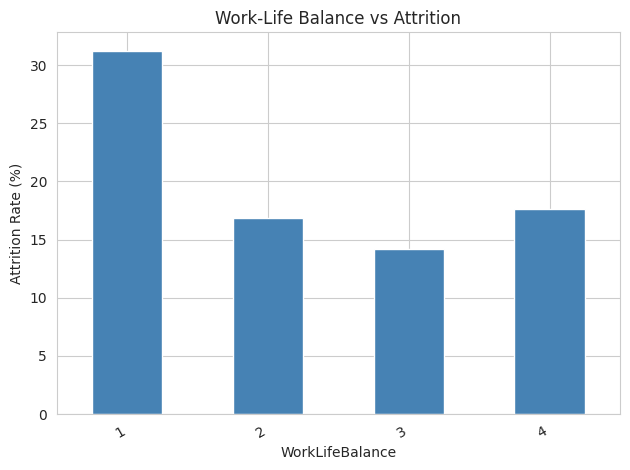

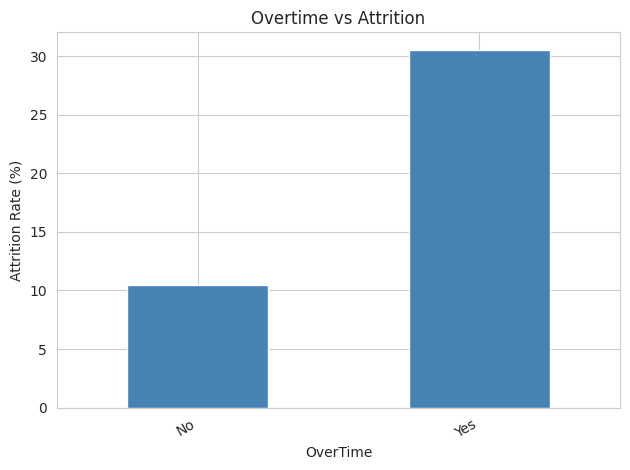

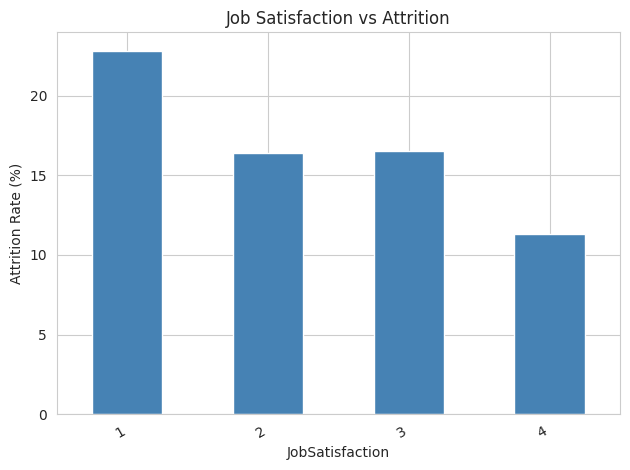

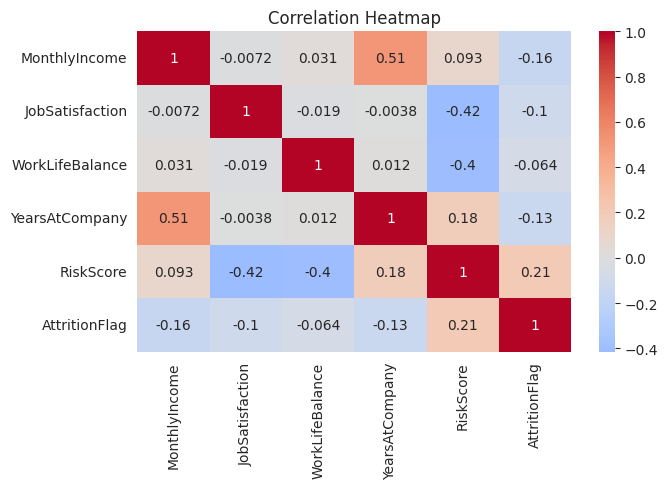

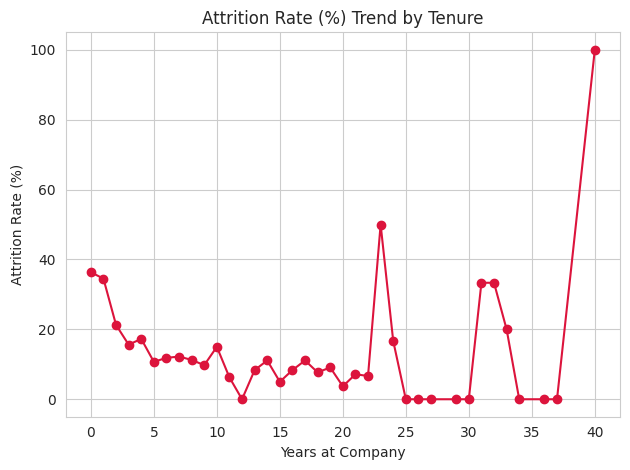

In [ ]:
from google.colab import files
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import plotly.graph_objects as go

uploaded = files.upload()  # upload HR_Analytics_Phase1_Cleaned.csv
df = pd.read_csv("HR_Analytics_Cleaned.csv")
sns.set_style("whitegrid")

# ---- KPI Cards (printed summary) ----
kpis = {
    "Total Employees": len(df),
    "Attrition Rate (%)": round((df["Attrition"]=="Yes").mean()*100,2),
    "Retention Rate (%)": round((df["Attrition"]=="No").mean()*100,2),
    "High Risk Count": (df["RetentionRisk"]=="High Risk").sum(),
}
print("KPI CARDS:", kpis)

# ---- Bar Charts: X vs Attrition ----
def bar_vs_attrition(col, order=None, title=""):
    rate = pd.crosstab(df[col], df["Attrition"], normalize="index")["Yes"]*100
    if order: rate = rate.reindex(order)
    rate.plot(kind="bar", color="steelblue"); plt.title(title)
    plt.ylabel("Attrition Rate (%)"); plt.xticks(rotation=30, ha="right")
    plt.tight_layout(); plt.show()

bar_vs_attrition("Department", title="Department vs Attrition")
bar_vs_attrition("SalaryBand", ["Low","Medium","High"], "Salary vs Attrition")
bar_vs_attrition("WorkLifeBalance", title="Work-Life Balance vs Attrition")
bar_vs_attrition("OverTime", title="Overtime vs Attrition")
bar_vs_attrition("JobSatisfaction", title="Job Satisfaction vs Attrition")

# ---- Heatmap: correlation of key drivers ----
cols = ["MonthlyIncome","JobSatisfaction","WorkLifeBalance","YearsAtCompany","RiskScore"]
tmp = df[cols].copy(); tmp["AttritionFlag"] = (df["Attrition"]=="Yes").astype(int)
plt.figure(figsize=(7,5))
sns.heatmap(tmp.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap"); plt.tight_layout(); plt.show()

# ---- Trend Chart: Attrition over YearsAtCompany (proxy trend) ----
df.groupby("YearsAtCompany")["Attrition"].apply(lambda x:(x=="Yes").mean()*100).plot(marker="o", color="crimson")
plt.title("Attrition Rate (%) Trend by Tenure"); plt.xlabel("Years at Company"); plt.ylabel("Attrition Rate (%)")
plt.tight_layout(); plt.show()

# ---- Funnel Analysis: workforce narrowing to high-risk leavers ----
funnel_stages = ["Total Employees", "Overtime Employees", "Low Satisfaction", "High Risk", "Attrited"]
funnel_values = [
    len(df),
    (df["OverTime"]=="Yes").sum(),
    (df["JobSatisfaction"]<=2).sum(),
    (df["RetentionRisk"]=="High Risk").sum(),
    (df["Attrition"]=="Yes").sum(),
]
go.Figure(go.Funnel(y=funnel_stages, x=funnel_values)).update_layout(title="Attrition Risk Funnel").show()

Saving HR_Analytics_Cleaned.csv to HR_Analytics_Cleaned (6).csv
Segment Sizes: {'High Risk': np.int64(230), 'High Performers': np.int64(226), 'Long-Term': np.int64(366), 'Overtime': np.int64(416), 'Dissatisfied': np.int64(569)}
Attrition Rate (%) by Segment: {'High Risk': np.float64(27.39), 'High Performers': np.float64(16.37), 'Long-Term': np.float64(10.38), 'Overtime': np.float64(30.53), 'Dissatisfied': np.float64(19.68)}


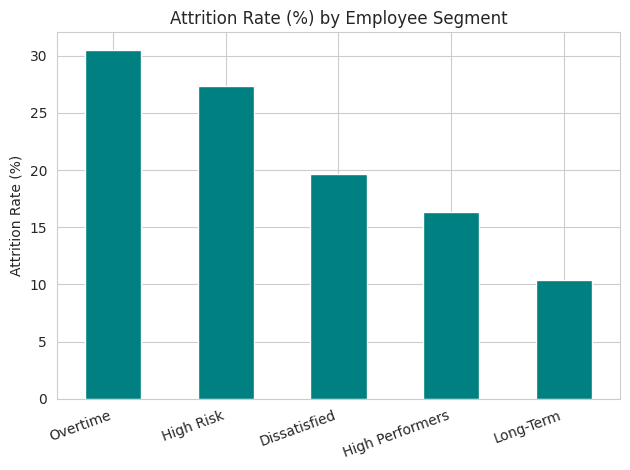

                       High Risk  High Performers  Long-Term  Overtime  \
Avg Job Satisfaction        2.00             2.73       2.75      2.77   
Avg Income               7515.10          6313.89    9534.49   6548.55   
Avg Tenure                  9.17             7.06      15.33      6.89   
Avg Work-Life Balance       2.27             2.77       2.76      2.73   

                       Dissatisfied  
Avg Job Satisfaction           1.49  
Avg Income                  6544.72  
Avg Tenure                     7.05  
Avg Work-Life Balance          2.77  


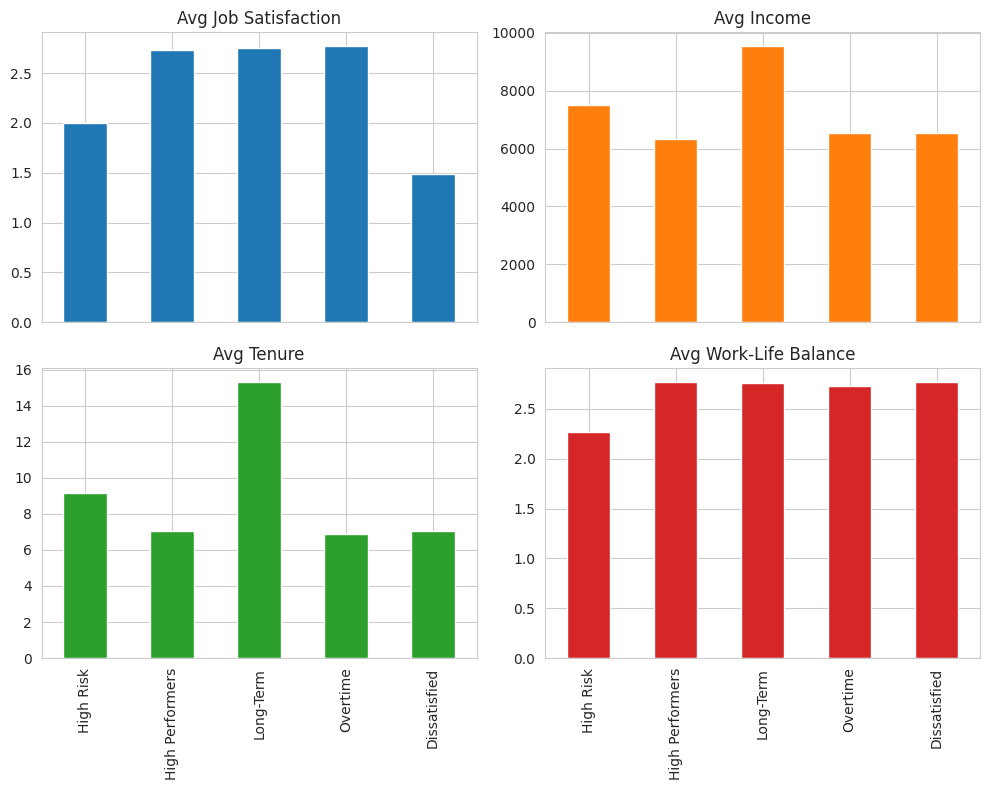

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns

uploaded = files.upload()  # upload HR_Analytics_Phase1_Cleaned.csv
df = pd.read_csv("HR_Analytics_Cleaned.csv")
sns.set_style("whitegrid")

# ---- Create employee segments ----
df["Seg_HighRisk"] = df["RetentionRisk"] == "High Risk"
df["Seg_HighPerformer"] = df["PerformanceRating"] >= 4
df["Seg_LongTerm"] = df["YearsAtCompany"] >= 10
df["Seg_Overtime"] = df["OverTime"] == "Yes"
df["Seg_Dissatisfied"] = df["JobSatisfaction"] <= 2

segments = {
    "High Risk": df["Seg_HighRisk"],
    "High Performers": df["Seg_HighPerformer"],
    "Long-Term": df["Seg_LongTerm"],
    "Overtime": df["Seg_Overtime"],
    "Dissatisfied": df["Seg_Dissatisfied"],
}

# ---- Segment sizes ----
sizes = {name: mask.sum() for name, mask in segments.items()}
print("Segment Sizes:", sizes)

# ---- Behavioral differences: Attrition rate per segment ----
attrition_by_seg = {name: round((df[mask]["Attrition"]=="Yes").mean()*100, 2) for name, mask in segments.items()}
print("Attrition Rate (%) by Segment:", attrition_by_seg)

pd.Series(attrition_by_seg).sort_values(ascending=False).plot(kind="bar", color="teal")
plt.title("Attrition Rate (%) by Employee Segment"); plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()

# ---- Behavioral differences: avg satisfaction, income, tenure per segment ----
behavior = pd.DataFrame({
    name: [
        round(df[mask]["JobSatisfaction"].mean(), 2),
        round(df[mask]["MonthlyIncome"].mean(), 2),
        round(df[mask]["YearsAtCompany"].mean(), 2),
        round(df[mask]["WorkLifeBalance"].mean(), 2),
    ] for name, mask in segments.items()
}, index=["Avg Job Satisfaction", "Avg Income", "Avg Tenure", "Avg Work-Life Balance"])

print(behavior)
behavior.T.plot(kind="bar", subplots=True, layout=(2,2), figsize=(10,8), legend=False)
plt.tight_layout(); plt.show()

# ---- Save segmented dataset ----
df.to_csv("HR_Analytics_Phase4_Segmented.csv", index=False)
files.download("HR_Analytics_Phase4_Segmented.csv")